# LIBRARY

In [22]:
%pip install scikit-plot -q
%pip install scipy -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [23]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt

In [24]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

# IMPORT CONTROL DATA SET 

In [4]:
file_path = "../1.DATASET/CMI_V2_CONTROL.csv"
df=pd.read_csv(file_path)
df

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,1,9,0,NaN,14.035590,48.00,46.0,70.0,NaN,3.0,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,3,9,0,71.0,18.292347,56.00,81.6,97.0,6.0,7.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,5,13,1,50.0,22.279952,59.50,112.2,73.0,5.0,8.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,6,10,0,NaN,19.660760,55.00,84.6,83.0,NaN,11.0,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,7,10,1,65.0,16.861286,59.25,84.2,90.0,5.0,4.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852,3952,15,0,40.0,26.364710,70.50,186.4,74.0,5.0,10.0,...,3.0,54.2027,91.4887,90.0,3.0,1.0,117.333333,23.714789,26.417470,8.527654
1853,3953,8,0,65.0,17.139810,52.50,67.2,65.0,NaN,12.0,...,1.0,20.2645,36.7181,58.0,2.0,0.0,77.333333,10.568299,18.526452,9.000000
1854,3954,7,1,NaN,13.927006,48.50,46.6,75.0,5.0,4.5,...,1.0,18.0937,30.0453,67.0,0.0,1.0,78.333333,9.540221,18.909726,8.750000
1855,3955,13,0,60.0,16.362460,59.50,82.4,70.0,NaN,12.0,...,1.0,29.7790,52.8320,50.0,1.0,1.0,82.000000,26.000000,18.950000,8.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      1857 non-null   int64  
 1   Basic_Demos-Age                         1857 non-null   int64  
 2   Basic_Demos-Sex                         1857 non-null   int64  
 3   CGAS-CGAS_Score                         1679 non-null   float64
 4   Physical-BMI                            1857 non-null   float64
 5   Physical-Height                         1857 non-null   float64
 6   Physical-Weight                         1857 non-null   float64
 7   Physical-HeartRate                      1853 non-null   float64
 8   Fitness_Endurance-Max_Stage             1206 non-null   float64
 9   FGC-FGC_TL                              1708 non-null   float64
 10  BIA-BIA_Activity_Level_num              1857 non-null   floa

# Data Cleaning

## Removing useless variables

In [6]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)

In [7]:
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,BIA-BIA_Activity_Level_num,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,9,0,NaN,14.035590,48.00,46.0,70.0,NaN,3.0,2.0,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,9,0,71.0,18.292347,56.00,81.6,97.0,6.0,7.0,3.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,13,1,50.0,22.279952,59.50,112.2,73.0,5.0,8.0,2.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,10,0,NaN,19.660760,55.00,84.6,83.0,NaN,11.0,2.0,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,10,1,65.0,16.861286,59.25,84.2,90.0,5.0,4.0,3.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875


# TARGET VARIABLES

## TARGET VARIABLE Physical-BMI

In [8]:
df_BMI = df[['Basic_Demos-Age','Basic_Demos-Sex','Physical-BMI', 'Physical-Weight', 
'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI']].copy()


### null values

In [10]:
df_BMI.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'Physical-BMI', 'Physical-Weight',
       'Physical-Height', 'BIA-BIA_FMI', 'BIA-BIA_FFMI'],
      dtype='object')

In [11]:
df_BMI.isnull().sum()

Basic_Demos-Age    0
Basic_Demos-Sex    0
Physical-BMI       0
Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_FFMI       1
dtype: int64

In [12]:
df_BMI=df_BMI.dropna(subset=['BIA-BIA_FFMI'])

In [13]:
df_BMI.isnull().sum()

Basic_Demos-Age    0
Basic_Demos-Sex    0
Physical-BMI       0
Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_FFMI       0
dtype: int64

### Partitioning

In [14]:
attributes = [col for col in df_BMI.columns if col != 'Physical-BMI']
X = df_BMI[attributes].values
y = np.array(df_BMI['Physical-BMI'])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [16]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 6) (464, 6) (1392,) (464,)


In [17]:
df_BMI.shape

(1856, 7)

### Randomized Search

In [116]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [18]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_bmi = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_bmi = random_search.best_estimator_

In [19]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 30, 'criterion': 'absolute_error'} -0.7820930063548797


In [20]:
dt_reg_bmi = random_search.best_estimator_
dt_reg_bmi.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=30,
                      min_samples_leaf=5, min_samples_split=0.001)

In [25]:
y_pred = dt_reg_bmi.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 0.7797
MAE  : 0.3376
R²   : 0.9715


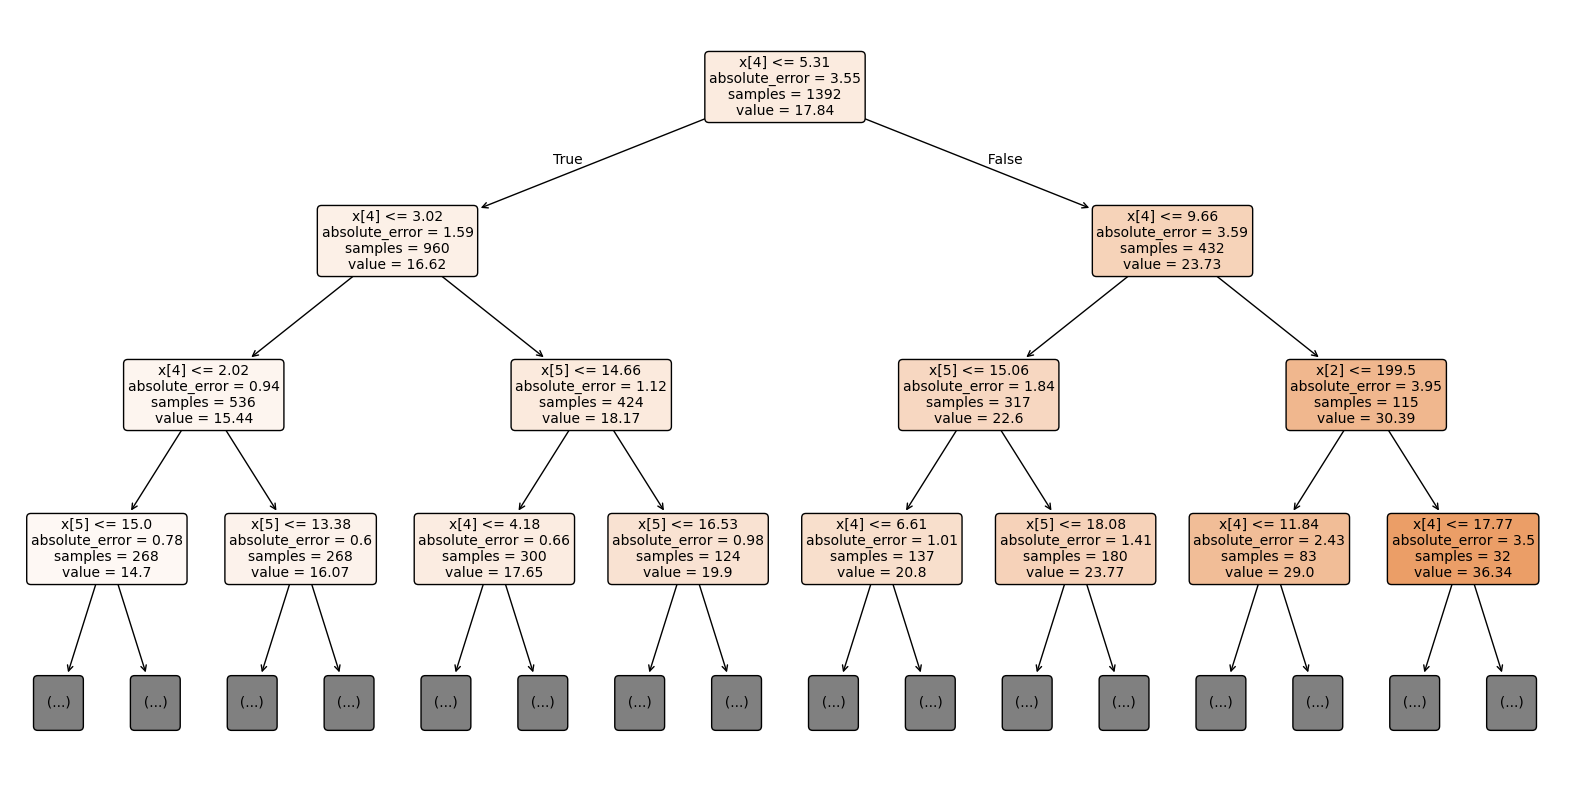

In [26]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_bmi,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 223 | 45.3060 |   37.1803 | 8.1257
 444 | 37.5496 |   32.6365 | 4.9131
 147 | 21.9336 |   26.6763 | 4.7427
 384 | 19.1567 |   14.5710 | 4.5858
  93 | 33.1049 |   29.0310 | 4.0739
 140 | 23.0412 |   18.9895 | 4.0516
 344 | 29.0906 |   32.6365 | 3.5459
 225 | 17.1590 |   13.6705 | 3.4885
 197 | 17.0109 |   20.2227 | 3.2119
 375 | 23.4266 |   20.2227 | 3.2039


C:\Users\paula\AppData\Local\Temp\ipykernel_5364\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


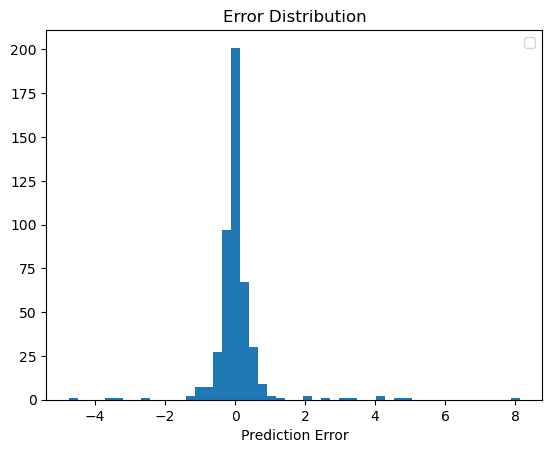

In [27]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [28]:
zipped = zip(attributes, dt_reg_bmi.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FMI 0.7745860100258807
BIA-BIA_FFMI 0.19273981907084117
Physical-Weight 0.03170986569130688
Physical-Height 0.0008007818210575741
Basic_Demos-Age 0.00012061279789715678
Basic_Demos-Sex 4.2910593016577203e-05


## TARGET VARIABLE Physical-Weight

In [ ]:
df_weight = df[['Basic_Demos-Age','Basic_Demos-Sex','Physical-BMI', 'Physical-Weight', 
             'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI']].copy()
# 

In [67]:
df_weight.isnull().sum()

Basic_Demos-Age    0
Physical-BMI       0
Physical-Height    0
Physical-Weight    0
dtype: int64

In [31]:
df_weight = df.copy()

### Partitioning

In [68]:
attributes = [col for col in df_weight.columns if col != 'Physical-Weight']
X = df_weight[attributes].values
y = np.array(df_weight['Physical-Weight'])

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [70]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (465, 3) (1392,) (465,)


In [71]:
df_weight.shape

(1857, 4)

### Randomized Search

In [ ]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [72]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_weight = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_weight = random_search.best_estimator_

In [73]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 20, 'criterion': 'friedman_mse'} -39.422829280932525


In [74]:
dt_reg_weight = random_search.best_estimator_
dt_reg_weight.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=20,
                      min_samples_leaf=5, min_samples_split=0.002)

In [75]:
y_pred = dt_reg_weight.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 5.1882
MAE  : 2.5541
R²   : 0.9833


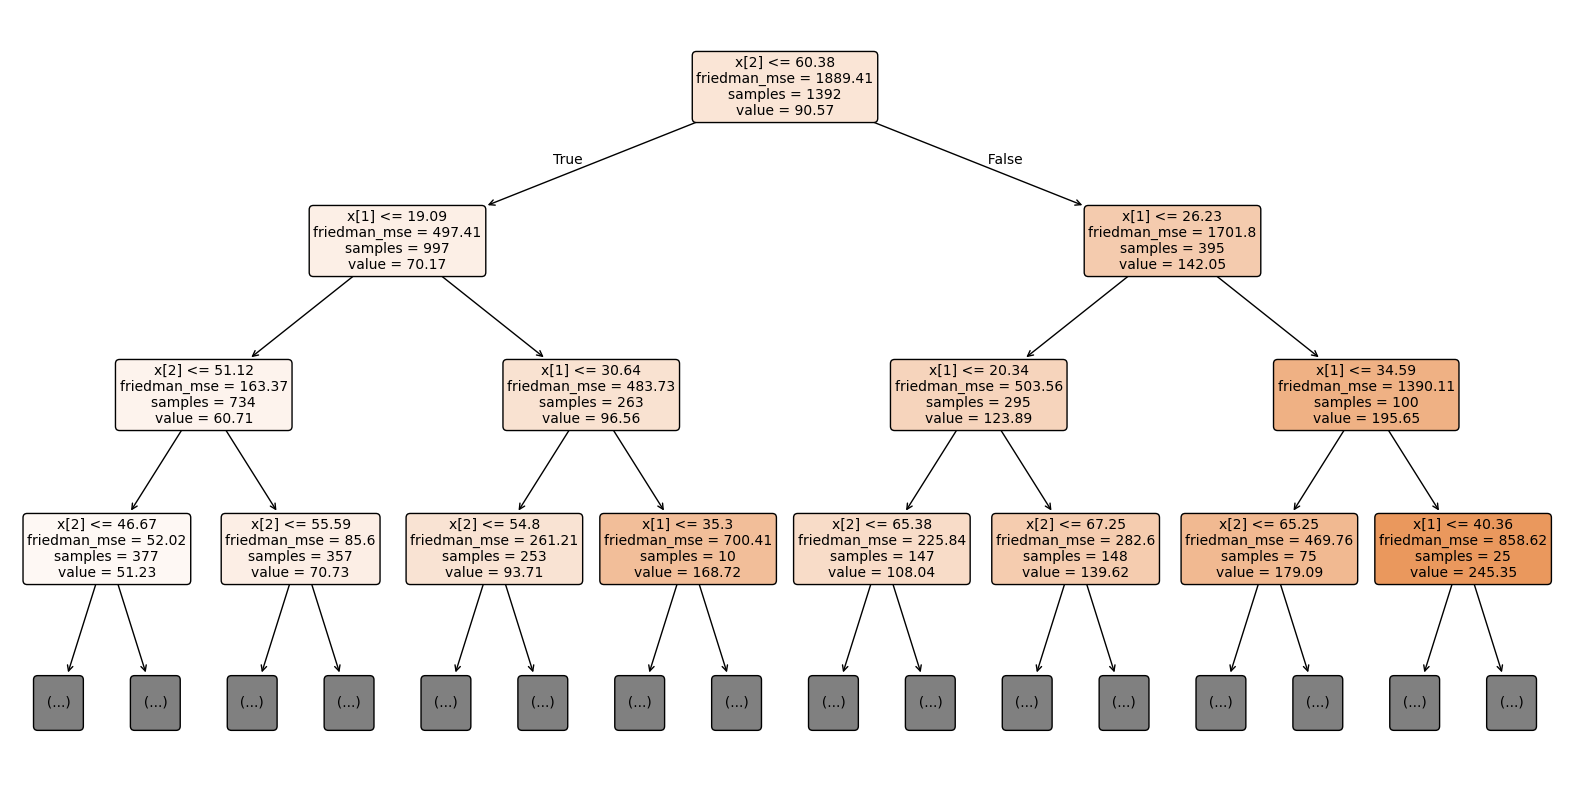

In [76]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_weight,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  24 | 252.8000 |  193.4857 | 59.3143
 372 | 231.2000 |  193.4857 | 37.7143
 311 | 115.2000 |  147.5600 | 32.3600
 130 | 224.2000 |  193.4857 | 30.7143
   9 | 155.8000 |  131.1143 | 24.6857
 415 | 183.8000 |  165.3250 | 18.4750
 366 | 306.4000 |  291.7200 | 14.6800
  30 | 199.2000 |  184.6000 | 14.6000
  77 | 74.6000 |   88.5625 | 13.9625
  44 | 179.0000 |  165.3250 | 13.6750


C:\Users\paula\AppData\Local\Temp\ipykernel_16596\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


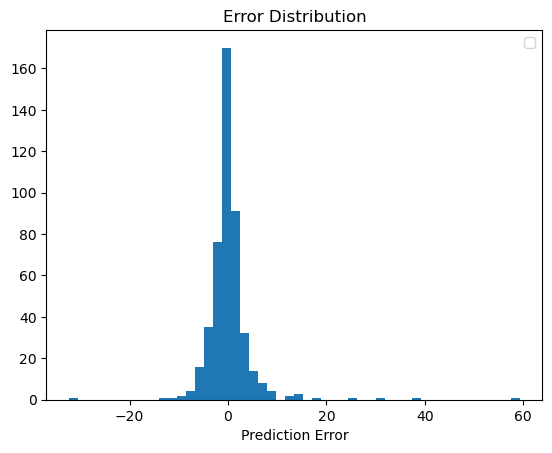

In [77]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [43]:
zipped = zip(attributes, dt_reg_weight.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_TBW 0.6913991174236389
BIA-BIA_Fat 0.1508817420068545
Physical-BMI 0.12388429812575678
BIA-BIA_SMM 0.022105030149351022
Physical-Height 0.009870704400267123
Physical-HeartRate 0.0006427676940941528
CGAS-CGAS_Score 0.0003365292246262824
Physical-MAP_CAL 0.00015562494509903756
BIA-BIA_DEE 0.00014909584334115849
BIA-BIA_BMI 0.00011098034384072197
FGC-FGC_SR_CAL 0.000104680052093768
PCIAT-PCIAT_Total 8.818915256028475e-05
BIA-BIA_BMC 7.60479274699537e-05
BIA-BIA_FFMI 5.6292533199916696e-05
BIA-BIA_FMI 5.3687789077007256e-05
Basic_Demos-Age 1.3254820613209074e-05
BIA-BIA_Activity_Level_num 1.2843351144799377e-05
PCIAT-PCIAT_Total_CAL 1.2146812396416628e-05
BIA-BIA_Frame_num 1.1466107796838896e-05
SDS-SDS_Total_T 9.633198346854772e-06
FGC-FGC_CORE_CAL 9.355288352302762e-06
FGC-FGC_TL 8.685935695849372e-06
FGC-FGC_GS_CAL 4.591903170080525e-06
Fitness_Endurance-Max_Stage 3.2349712130973122e-06
Basic_Demos-Sex 0.0
PreInt_EduHx-computerinternet_hoursday 0.0
sii 0.0


## TARGET VARIABLE Physical-Height

In [78]:
df_height = df[['Basic_Demos-Age',  'Physical-BMI','Physical-Height', 'Physical-Weight']].copy()
# 

In [79]:
df_height.isnull().sum()

Basic_Demos-Age    0
Physical-BMI       0
Physical-Height    0
Physical-Weight    0
dtype: int64

In [ ]:
df_height = df.copy()

### Partitioning

In [80]:
attributes = [col for col in df_height.columns if col != 'Physical-Height']
X = df_height[attributes].values
y = np.array(df_height['Physical-Height'])

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [82]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (465, 3) (1392,) (465,)


In [83]:
df_height.shape

(1857, 4)

### Randomized Search

In [ ]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [84]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_height = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_height = random_search.best_estimator_

In [85]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 47, 'criterion': 'absolute_error'} -2.178294244991104


In [86]:
dt_reg_height = random_search.best_estimator_
dt_reg_height.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=47,
                      min_samples_leaf=5, min_samples_split=0.001)

In [87]:
y_pred = dt_reg_height.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.4599
MAE  : 0.9794
R²   : 0.9594


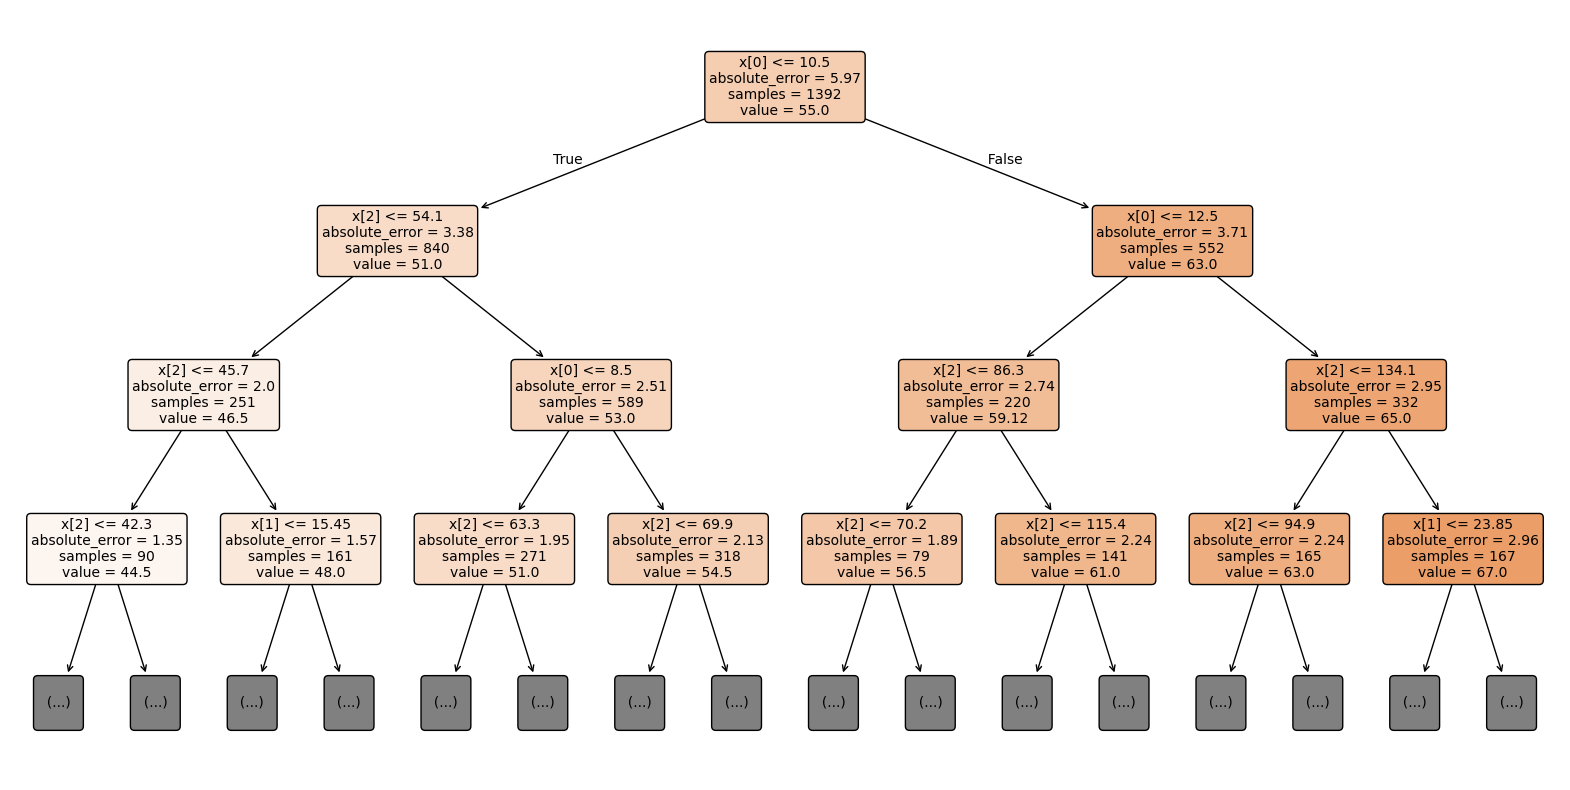

In [88]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  77 | 41.5000 |   51.0000 | 9.5000
 311 | 49.0000 |   57.0000 | 8.0000
  24 | 77.5000 |   70.2500 | 7.2500
 130 | 74.5000 |   67.5000 | 7.0000
 417 | 62.9000 |   58.0000 | 4.9000
 123 | 60.0000 |   55.2500 | 4.7500
 117 | 65.0000 |   60.7500 | 4.2500
 226 | 57.7500 |   62.0000 | 4.2500
 372 | 74.5000 |   70.2500 | 4.2500
 358 | 58.0000 |   62.0000 | 4.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_16596\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


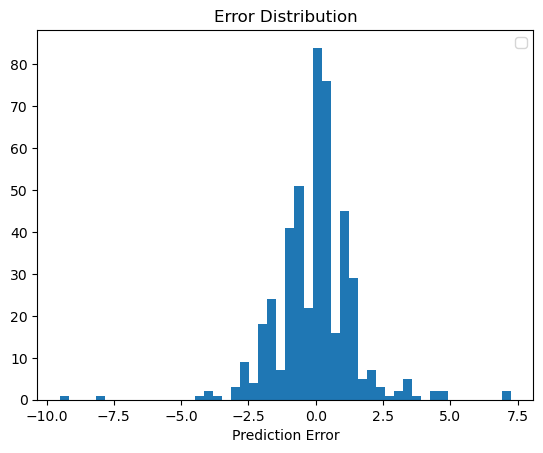

In [89]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [90]:
zipped = zip(attributes, dt_reg_height.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.5598214155289344
Physical-Weight 0.30742079032393
Physical-BMI 0.13275779414713557


# IMPORT DATASET

In [31]:
file_path = "../1.DATASET/CMI_V2.csv"
df_notna=pd.read_csv(file_path)
df_notna

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.00,50.8,NaN,5.0,6.0,...,1.0,19.541300,32.690900,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.500000
1,1,9,0,NaN,14.035590,48.00,46.0,70.0,NaN,3.0,...,1.0,15.410700,27.055200,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
2,2,10,1,71.0,16.648696,56.50,75.6,94.0,5.0,5.0,...,NaN,NaN,44.987000,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.000000
3,3,9,0,71.0,18.292347,56.00,81.6,97.0,6.0,7.0,...,2.0,26.479800,45.996600,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
4,4,18,1,65.0,17.937682,NaN,77.0,NaN,NaN,10.0,...,2.0,NaN,NaN,NaN,1.0,0.0,90.152104,12.000000,26.463732,8.003205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1,NaN,16.130585,46.07,49.0,82.5,2.5,8.0,...,1.0,NaN,31.583004,55.0,0.0,0.0,81.861037,6.500000,18.075000,7.000000
8456,8456,10,1,69.5,NaN,56.13,47.8,80.5,5.0,8.0,...,1.0,22.983200,36.475662,NaN,0.0,1.0,79.833333,8.500000,13.575000,5.000000
8457,8457,10,1,70.0,40.937571,49.56,47.2,83.5,7.0,NaN,...,2.0,31.594712,35.106855,NaN,2.0,0.0,82.166667,21.500000,16.840263,9.500000
8458,8458,15,1,55.5,NaN,63.79,99.5,87.5,NaN,9.0,...,2.0,46.467581,57.530686,NaN,1.0,2.0,88.395702,10.000000,26.417470,10.500000


In [32]:
df_notna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Age                         8460 non-null   int64  
 2   Basic_Demos-Sex                         8460 non-null   int64  
 3   CGAS-CGAS_Score                         7034 non-null   float64
 4   Physical-BMI                            7591 non-null   float64
 5   Physical-Height                         7595 non-null   float64
 6   Physical-Weight                         7641 non-null   float64
 7   Physical-HeartRate                      7539 non-null   float64
 8   Fitness_Endurance-Max_Stage             5480 non-null   float64
 9   FGC-FGC_TL                              6945 non-null   float64
 10  BIA-BIA_Activity_Level_num              6636 non-null   floa

# REPLACE NULL VALUES

## Physical-BMI

In [49]:
attributes = ['id','Basic_Demos-Age','Basic_Demos-Sex','Physical-BMI', 'Physical-Weight', 
                'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI']
df_unknown=df_notna[attributes][df_notna['Physical-BMI'].isna()].copy()

df_unknown.isnull().sum()

id                   0
Basic_Demos-Age      0
Basic_Demos-Sex      0
Physical-BMI       869
Physical-Weight    259
Physical-Height    276
BIA-BIA_FMI        317
BIA-BIA_FFMI       304
dtype: int64

In [50]:
df_unknown=df_unknown.dropna(subset=['Physical-Weight', 
                'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI'])
df_unknown.isnull().sum()

id                   0
Basic_Demos-Age      0
Basic_Demos-Sex      0
Physical-BMI       249
Physical-Weight      0
Physical-Height      0
BIA-BIA_FMI          0
BIA-BIA_FFMI         0
dtype: int64

In [53]:
attributes = [col for col in df_unknown.columns if col not in ['Physical-BMI','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_bmi.predict(X_unknown)

In [58]:
df_unknown['Physical-BMI_DT'] = predicted_value
df_unknown=df_unknown[['id','Physical-BMI_DT']]
df_unknown

C:\Users\paula\AppData\Local\Temp\ipykernel_5364\2333317356.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unknown['Physical-BMI_DT'] = predicted_value


,id,Physical-BMI_DT
11,11,17.848066
145,145,17.848066
229,229,17.848066
288,288,17.848066
360,360,17.848066
...,...,...
8352,8352,22.874358
8393,8393,17.424447
8417,8417,15.810700
8438,8438,16.755328


In [59]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['Physical-BMI'].isnull())) , 'Physical-BMI'] = df_notna['Physical-BMI_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                               620
Physical-Height                            865
Physical-Weight                            819
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_Frame_num                         1824
BIA-BIA_SMM                               1824
BIA-BIA_TBW  